In [ ]:
# Load required libraries
library(here)
suppressPackageStartupMessages(library(brms))
suppressPackageStartupMessages(library(tidyverse))
library(ggplot2)
library(bayesplot)
library(readr)

n <- 3000
quantiles <- c(0.5, 0.7, 0.9, 0.95, 0.97, 0.99)


In [ ]:
set.seed(1337)

synthetic_data <- tibble(
    x1 = rnorm(n, mean = 5, sd = 1),
    x2 = runif(n, min = 0, max = 10),
    x3 = rexp(n, rate = 0.2),
    y = rnorm(n, mean = 10, sd = 3)
)

cor_mat <- round(cor(synthetic_data), 4)
print(cor_mat)

cor_mat |>
    as.data.frame() |>
    rownames_to_column() |>
    rename(var = rowname) |>
    readr::write_csv(here("reports", "tables", "synthetic_correlation_matrix.csv"))


        x1      x2      x3       y
x1  1.0000  0.0148 -0.0252  0.0196
x2  0.0148  1.0000  0.0178 -0.0062
x3 -0.0252  0.0178  1.0000  0.0040
y   0.0196 -0.0062  0.0040  1.0000


In [13]:
results <- tibble(
    quantile = numeric(),
    bayes_r2_mean = numeric(),
    bayes_r2_lower = numeric(),
    bayes_r2_upper = numeric(),
    model = list()
)


cat("Running Bayesian quantile regressions...\n")

# Loop through each quantile
for (i in seq_along(quantiles)) {
    q <- quantiles[i]

    print(paste("Processing", q))

    # Fit Bayesian quantile regression
    model <- brm(
        brms::bf(y ~ x1 + x2 + x3, quantile = q),
        data = synthetic_data,
        family = asym_laplace(),
        prior = c(
            prior(normal(0, 5), class = Intercept),
            prior(normal(0, 2), class = b)
        ),
        iter = 2000,
        warmup = 1000,
        chains = 4,
        cores = 4,
        threads = threading(2),
        seed = 42 + i,
        refresh = 0, # Suppress output
        silent = 2 # Suppress warnings
    )

    # Calculate Bayes R²
    bayes_r2_samples <- bayes_R2(model)
    bayes_r2_summary <- posterior_summary(bayes_r2_samples)

    # Store results
    results <- results %>%
        add_row(
            quantile = q,
            bayes_r2_mean = bayes_r2_summary[1, "Estimate"],
            bayes_r2_lower = bayes_r2_summary[1, "Q2.5"],
            bayes_r2_upper = bayes_r2_summary[1, "Q97.5"],
            model = list(model)
        )
}


Running Bayesian quantile regressions...
[1] "Processing 0.5"
[1] "Processing 0.7"
[1] "Processing 0.9"
[1] "Processing 0.95"
[1] "Processing 0.97"
[1] "Processing 0.99"


In [14]:
print(results |> select(-model))


# A tibble: 6 × 4
  quantile bayes_r2_mean bayes_r2_lower bayes_r2_upper
     <dbl>         <dbl>          <dbl>          <dbl>
1     0.5        0.00173        0.00173        0.00173
2     0.7        0.00238        0.00238        0.00238
3     0.9        0.00232        0.00232        0.00232
4     0.95       0.00205        0.00205        0.00205
5     0.97       0.00759        0.00759        0.00759
6     0.99       0.00181        0.00181        0.00181


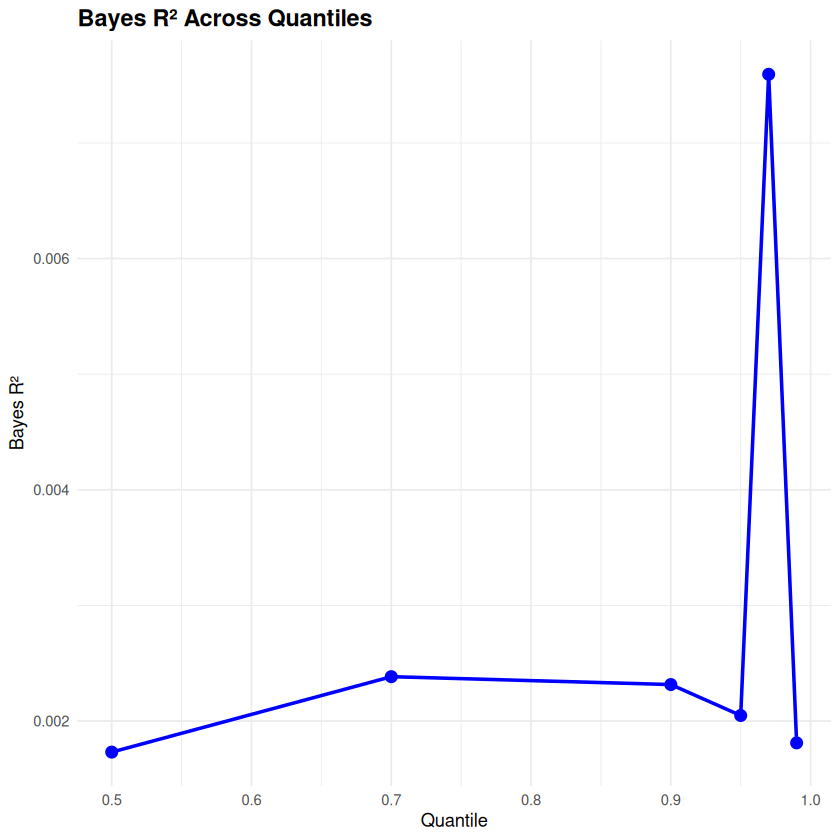

In [ ]:
# Create visualization
plot <- ggplot(results, aes(x = quantile, y = bayes_r2_mean)) +
    geom_line(color = "blue", size = 1) +
    geom_point(color = "blue", size = 3) +
    labs(
        title = "Bayes R² Across Quantiles",
        x = "Quantile",
        y = "Bayes R²",
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(size = 9, face = "bold"),
        plot.subtitle = element_text(size = 9, color = "gray60")
    )

print(plot)


In [ ]:
path <- here("reports", "figures", "bayes_r2_synthetic.jpg")
if (file.exists(path)) file.remove(path)
ggsave(
    path,
    plot,
    dpi = 300,
    units = "cm",
    width = 12,
    height = 10
)


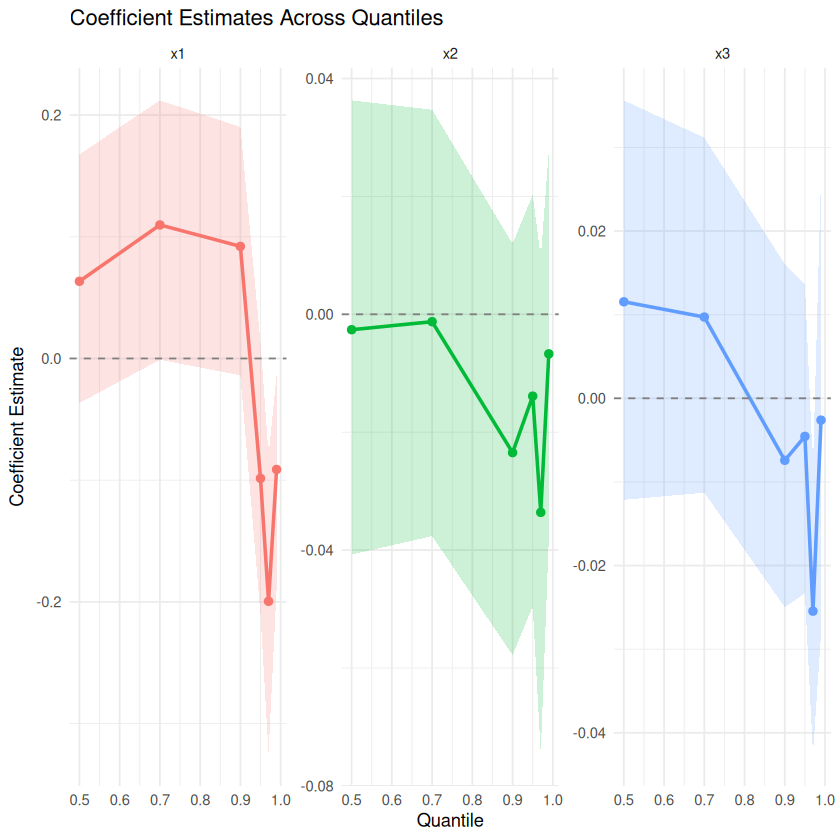

In [ ]:
# Create a comparison plot of coefficient estimates across quantiles
coef_results <- tibble(
    quantile = numeric(),
    parameter = character(),
    estimate = numeric(),
    lower = numeric(),
    upper = numeric()
)

for (i in seq_along(quantiles)) {
    model_summary <- posterior_summary(results$model[[i]])

    # Extract coefficient estimates (excluding intercept and sigma)
    coef_rows <- grep("^b_[^I]", rownames(model_summary))

    for (j in coef_rows) {
        param_name <- gsub("b_", "", rownames(model_summary)[j])

        coef_results <- coef_results %>%
            add_row(
                quantile = quantiles[i],
                parameter = param_name,
                estimate = model_summary[j, "Estimate"],
                lower = model_summary[j, "Q2.5"],
                upper = model_summary[j, "Q97.5"]
            )
    }
}

# Plot coefficient estimates across quantiles
plot <- ggplot(coef_results, aes(x = quantile, y = estimate, color = parameter)) +
    geom_line(linewidth = 1) +
    geom_point(size = 2) +
    geom_ribbon(aes(ymin = lower, ymax = upper, fill = parameter),
        alpha = 0.2, color = NA
    ) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
    facet_wrap(~parameter, scales = "free_y") +
    labs(
        title = "Coefficient Estimates Across Quantiles",
        x = "Quantile",
        y = "Coefficient Estimate"
    ) +
    theme_light() +
    theme(legend.position = "none")

print(plot)


In [ ]:
path <- here("reports", "figures", "bayes_r2_synthetic_coefficients.jpg")
if (file.exists(path)) file.remove(path)
ggsave(
    path,
    plot,
    dpi = 300,
    units = "cm",
    width = 17,
    height = 11
)
